# Exploratory Data Analysis - MagnaTagATune & Music Structure Graphs

Covers the corpus, the tag vocabulary and the graphs the models actually consume.

Run `python scripts/preprocess.py` first.

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.utils import load_config, resolve
from src.dataset import load_vocabulary
from src.graph_builder import graph_summary

cfg = load_config(ROOT / "config.yaml")
processed = resolve(cfg, "processed_dir")
raw = resolve(cfg, "raw_dir")
plt.rcParams["figure.dpi"] = 110
print("processed:", processed)

processed: E:\425 final project\gnn-bert-music-context\data\processed


## 1. Corpus and splits

In [2]:
manifest = pd.read_csv(processed / "manifest.csv")
label_tags, auxiliary_tags = load_vocabulary(processed)

print(f"clips            : {len(manifest):,}")
print(f"label tags       : {len(label_tags)}")
print(f"auxiliary tags   : {len(auxiliary_tags)}")
print(f"unique artists   : {manifest['artist'].nunique():,}")
print(f"unique albums    : {manifest['album'].nunique():,}")
print()
print(manifest["split"].value_counts().rename("clips").to_frame())

clips            : 21,355
label tags       : 50
auxiliary tags   : 84
unique artists   : 230
unique albums    : 446

       clips
split       
train  15425
test    4392
val     1538


### Leakage check

MTAT's `0`-`f` directories group clips by album folder, so the official split is
also an album-level split. Confirm no artist appears in both train and test.

In [3]:
train_artists = set(manifest.loc[manifest.split == "train", "artist"])
test_artists = set(manifest.loc[manifest.split == "test", "artist"])
overlap = train_artists & test_artists
print(f"artists in train : {len(train_artists)}")
print(f"artists in test  : {len(test_artists)}")
print(f"overlap          : {len(overlap)}")
if overlap:
    print("  e.g.", list(overlap)[:5])
else:
    print("  -> no artist leakage across the train/test boundary")

artists in train : 190
artists in test  : 75
overlap          : 45
  e.g. ['Seismic Anamoly', 'Yongen', 'touchingGrace', 'Jeff Wahl', 'Jade Leary']


## 2. Tag distribution

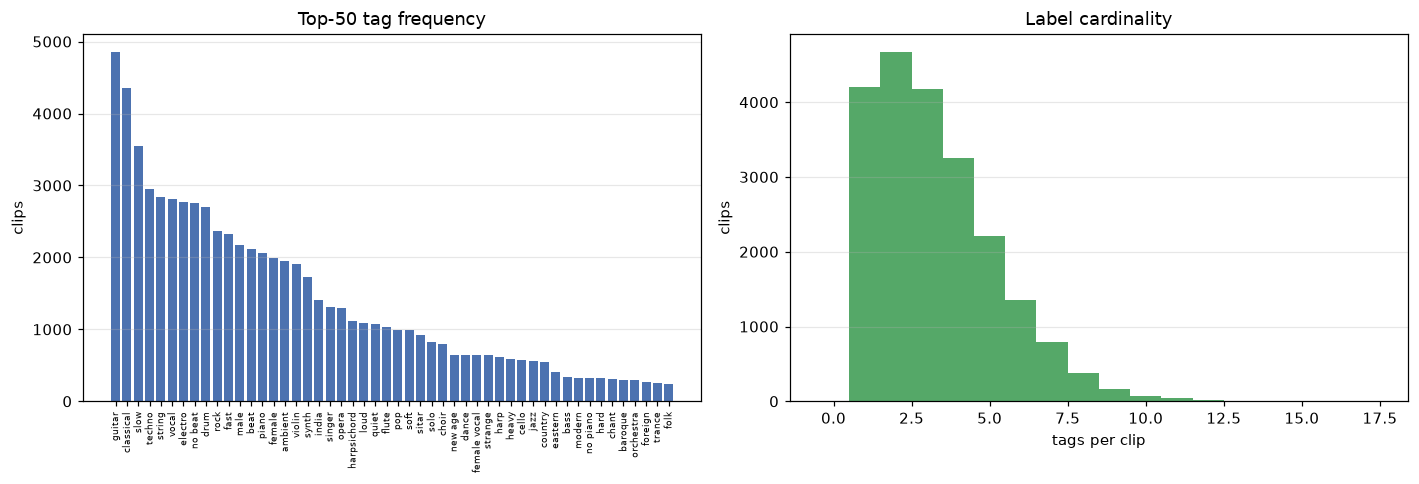

most common : guitar (22.8% of clips)
rarest      : folk (1.1% of clips)
mean positive rate across tags: 6.5%
median tags per clip: 3


In [4]:
counts = manifest[label_tags].sum().sort_values(ascending=False)
positives_per_clip = manifest[label_tags].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(len(counts)), counts.values, color="#4C72B0")
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(counts.index, rotation=90, fontsize=6)
axes[0].set_ylabel("clips"); axes[0].set_title("Top-50 tag frequency")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(positives_per_clip, bins=range(0, int(positives_per_clip.max()) + 2),
             color="#55A868", align="left")
axes[1].set_xlabel("tags per clip"); axes[1].set_ylabel("clips")
axes[1].set_title("Label cardinality"); axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

rate = counts / len(manifest)
print(f"most common : {counts.index[0]} ({rate.iloc[0]:.1%} of clips)")
print(f"rarest      : {counts.index[-1]} ({rate.iloc[-1]:.1%} of clips)")
print(f"mean positive rate across tags: {rate.mean():.1%}")
print(f"median tags per clip: {positives_per_clip.median():.0f}")

The positive rate is what motivates `pos_weight` in the BCE loss and the
validation-fitted per-tag thresholds: an unweighted model can score well on
accuracy by predicting all-zeros.

## 3. The text modality

In [5]:
for text in manifest["context_text"].head(3):
    print("-", text[:220], "\n")

lengths = manifest["context_text"].str.split().str.len()
print(f"context length (words): mean {lengths.mean():.1f}, median {lengths.median():.0f}, max {lengths.max()}")
print(f"unique context strings: {manifest['context_text'].nunique():,} of {len(manifest):,} clips")
print("(repeats are clips cut from the same source track - masked as non-negatives in Task 4)")

- The track is titled 'BWV54 - I Aria' by American Bach Soloists, from the album 'J.S. Bach Solo Cantatas'. 

- The track is titled 'BWV54 - I Aria' by American Bach Soloists, from the album 'J.S. Bach Solo Cantatas'. 

- The track is titled 'BWV54 - I Aria' by American Bach Soloists, from the album 'J.S. Bach Solo Cantatas'. 

context length (words): mean 18.6, median 18, max 47
unique context strings: 10,305 of 21,355 clips
(repeats are clips cut from the same source track - masked as non-negatives in Task 4)


## 4. Music structure graphs

In [6]:
examples = json.loads((processed / "examples" / "example_graphs.json").read_text())
frame = pd.DataFrame(examples)
edge_frame = pd.json_normalize(frame["edges_by_type"])
print(frame[["clip_id", "num_nodes", "num_segments", "num_chords", "num_edges", "feature_dim"]].describe().round(1))
print()
print("mean edges by type:")
print(edge_frame.mean().round(1))

       clip_id  num_nodes  num_segments  num_chords  num_edges  feature_dim
count     20.0       20.0          20.0        20.0       20.0         20.0
mean      59.3       32.0          10.0        22.0      410.6        280.0
std       15.4        1.8           0.0         1.8       40.7          0.0
min       29.0       28.0          10.0        18.0      331.0        280.0
25%       48.8       31.8          10.0        21.8      393.5        280.0
50%       59.5       32.0          10.0        22.0      412.0        280.0
75%       73.2       33.2          10.0        23.2      444.5        280.0
max       80.0       34.0          10.0        24.0      464.0        280.0

mean edges by type:
temporal             50.0
similarity           78.9
chord_transition     94.9
membership          186.8
dtype: float64


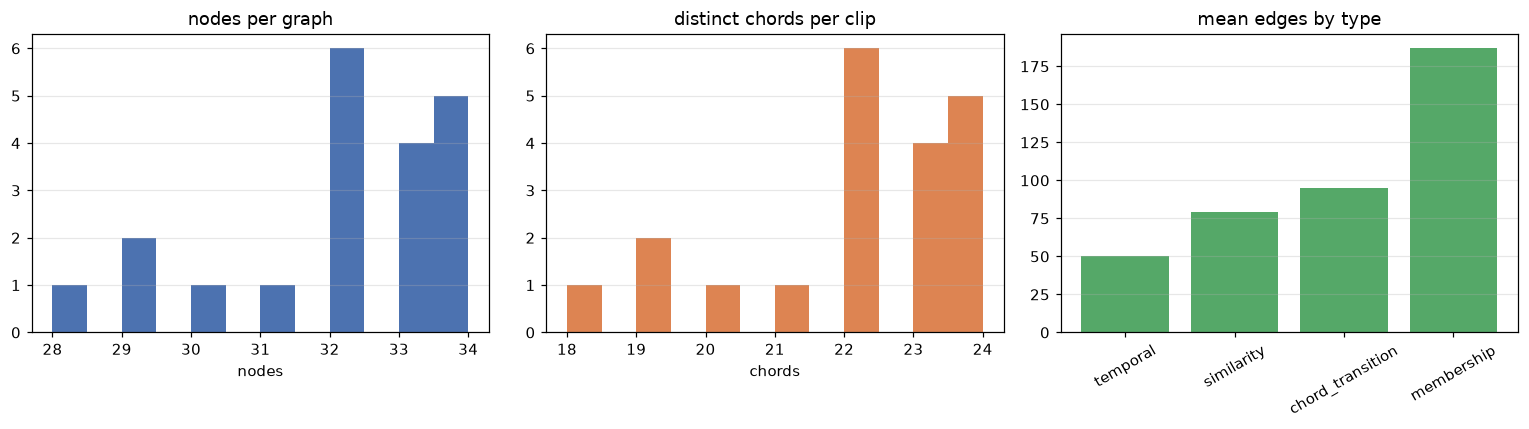

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(frame["num_nodes"], bins=12, color="#4C72B0")
axes[0].set_title("nodes per graph"); axes[0].set_xlabel("nodes")
axes[1].hist(frame["num_chords"], bins=12, color="#DD8452")
axes[1].set_title("distinct chords per clip"); axes[1].set_xlabel("chords")
axes[2].bar(edge_frame.columns, edge_frame.mean().values, color="#55A868")
axes[2].set_title("mean edges by type"); axes[2].tick_params(axis="x", rotation=30)
for ax in axes: ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

### Visualising one graph

graph_clip29.pt {'num_nodes': 32, 'num_segments': 10, 'num_chords': 22, 'num_edges': 460, 'edges_by_type': {'temporal': 50, 'similarity': 80, 'chord_transition': 110, 'membership': 220}, 'feature_dim': 280}
chords: C#:maj,F#:min,A:maj,C#:min,A:maj,D:min,A#:maj,A#:min,A#:maj,A#:min,A#:maj,E:min,A#:maj,E:min,C:maj,C#:min,C:maj,E:min,C:


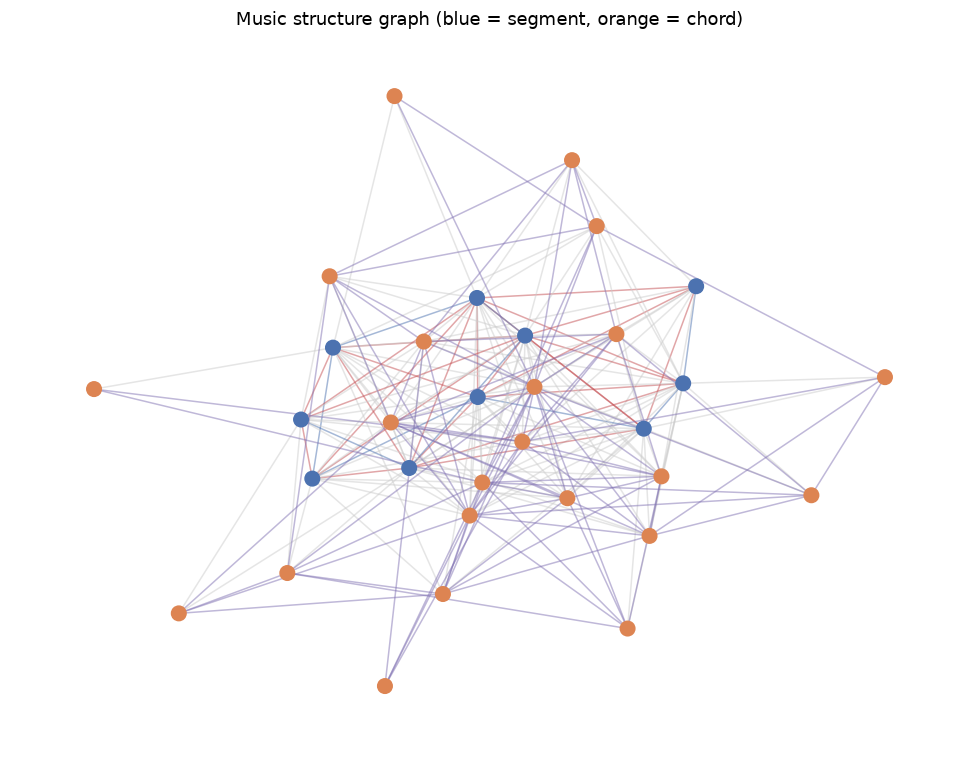

In [8]:
import networkx as nx
from src.graph_builder import NODE_CHORD, EDGE_SIMILARITY, EDGE_CHORD_TRANSITION, EDGE_MEMBERSHIP

path = sorted((processed / "examples").glob("graph_clip*.pt"))[0]
data = torch.load(path, weights_only=False)
print(path.name, graph_summary(data))
print("chords:", data.chord_sequence[:120])

G = nx.Graph()
for i in range(data.num_nodes):
    G.add_node(i, kind="chord" if int(data.node_type[i]) == NODE_CHORD else "segment")
edge_colours = {EDGE_SIMILARITY: "#C44E52", EDGE_CHORD_TRANSITION: "#8172B3", EDGE_MEMBERSHIP: "#cccccc"}
for k in range(data.edge_index.shape[1]):
    a, b = int(data.edge_index[0, k]), int(data.edge_index[1, k])
    if a == b:
        continue
    G.add_edge(a, b, color=edge_colours.get(int(data.edge_type[k]), "#4C72B0"))

pos = nx.spring_layout(G, seed=42, k=0.5)
node_colours = ["#DD8452" if G.nodes[n]["kind"] == "chord" else "#4C72B0" for n in G]
edge_colour_list = [G.edges[e]["color"] for e in G.edges]

plt.figure(figsize=(9, 7))
nx.draw_networkx_edges(G, pos, edge_color=edge_colour_list, alpha=0.5, width=1.0)
nx.draw_networkx_nodes(G, pos, node_color=node_colours, node_size=90)
plt.title("Music structure graph (blue = segment, orange = chord)")
plt.axis("off"); plt.tight_layout(); plt.show()

Blue nodes are 5 s windows chained temporally, with red edges marking acoustically
repeated segments (song form). Orange chord nodes connect through purple
transition edges and attach to the windows they sound in.

## 5. Node feature sanity check

node features: (32, 280)  (128 mel mean + 128 mel std + 12 chroma mean + 12 chroma std)
finite: True  range: [-41.36, 21.46]


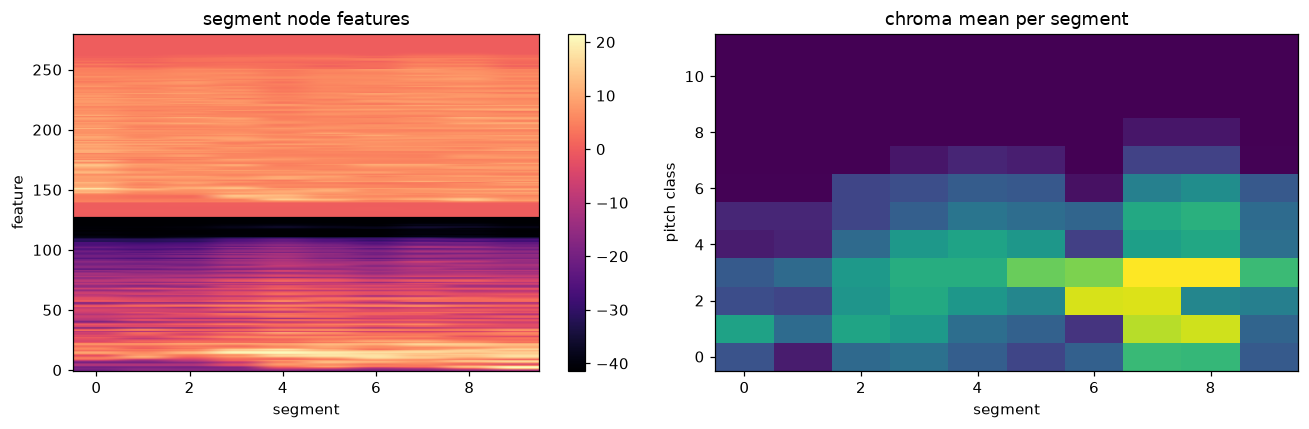

In [9]:
x = data.x.numpy()
print(f"node features: {x.shape}  (128 mel mean + 128 mel std + 12 chroma mean + 12 chroma std)")
print(f"finite: {np.isfinite(x).all()}  range: [{x.min():.2f}, {x.max():.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(x[: int(data.n_segments)].T, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title("segment node features"); axes[0].set_xlabel("segment"); axes[0].set_ylabel("feature")
plt.colorbar(im, ax=axes[0])
axes[1].imshow(x[: int(data.n_segments), 256:268].T, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title("chroma mean per segment"); axes[1].set_xlabel("segment"); axes[1].set_ylabel("pitch class")
plt.tight_layout(); plt.show()